In [10]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent ))

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [12]:
from src.dominick import DominickDataLoader

In [13]:
from src.nn.data import (
    ColumnEncoder,
    DatasetSchema,
    DemandDataset,
    DataLoaderFactory,
    SplineBuilder
)

from src.nn.embeddings import DemandContextEmbeddings
from src.nn.spline import CubicSplineBasis
from src.nn.models import IntegrableDemandHead1D, ICDN_1D
from src.nn.loss import ElasticityLoss
from src.nn.training import EpochRunner
from src.nn.data.preprocessing import LagFeatureBuilder

# Cargar y Preparar Datos

In [14]:
loader = DominickDataLoader()
df = loader.load("elasticity_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Dataset shape: (1966147, 10)
Columnas: ['store_code', 'upc_code', 'week_id', 'liters_per_upc', 'on_promo', 'promo_B', 'promo_C', 'promo_S', 'log_price_per_liter', 'log_liters_sold']


# Factorizar colmnas Categóricas

In [15]:
# Usar ColumnEncoder para factorizar
encoder = ColumnEncoder()

categorical_mappings = {}
for col in ["store_code", "upc_code", "week_id"]:
    codes, categories = encoder.factorize(df, col, sort=True)
    df[col] = codes
    categorical_mappings[col] = categories
    print(f"{col}: {len(categories)} categorías únicas")

n_stores = len(categorical_mappings["store_code"])
n_upcs = len(categorical_mappings["upc_code"])
n_weeks = len(categorical_mappings["week_id"])

print(f"\nMetadatos:")
print(f"  - Tiendas: {n_stores}")
print(f"  - UPCs: {n_upcs}")
print(f"  - Semanas: {n_weeks}")

store_code: 89 categorías únicas
upc_code: 787 categorías únicas
week_id: 302 categorías únicas

Metadatos:
  - Tiendas: 89
  - UPCs: 787
  - Semanas: 302


# Temporal Split

In [16]:
sorted_weeks = sorted(df["week_id"].unique())
week_threshold = sorted_weeks[int(len(sorted_weeks) * 0.8)]
train_df_raw = df[df["week_id"] < week_threshold]
val_df_raw   = df[df["week_id"] >= week_threshold]

# Lag

In [17]:
lag_builder = LagFeatureBuilder()
df = lag_builder.fit(train_df_raw).build(df)
lag_cols = [c for c in df.columns if 'lag' in c or 'rolling' in c or 'delta' in c or 'weeks_since' in c or 'week_gap' in c]
n_lags = len(lag_cols)

print(f"\nLag features:")
print(f"  - New columns: {lag_cols}")
print(f"  - Number of lags: {n_lags}")


Lag features:
  - New columns: ['lag_y_1', 'lag_y_2', 'lag_y_4', 'rolling_mean_y_4', 'rolling_mean_y_13', 'lag_y_1_missing', 'lag_y_2_missing', 'lag_y_4_missing', 'rolling_mean_y_4_missing', 'rolling_mean_y_13_missing', 'lag_x_1', 'delta_x_1', 'rolling_mean_x_4', 'lag_onpromo_1', 'lag_onpromo_2', 'weeks_since_promo', 'week_gap_1']
  - Number of lags: 17


# Split Train/Val


In [18]:
# Split definitivo (últimas semanas para validación)

train_df = df[df["week_id"] < week_threshold].copy()
val_df = df[df["week_id"] >= week_threshold].copy()

print(f"Train size: {len(train_df):,}")
print(f"Val size: {len(val_df):,}")

Train size: 1,729,044
Val size: 237,103


# Crear Dataset y DataLoaders

In [19]:
# Definir esquema (con validación)
schema = DatasetSchema()

# Crear datasets
train_dataset = DemandDataset(train_df, schema=schema, validate=True)
val_dataset = DemandDataset(val_df, schema=schema, validate=True)

print(f"Train dataset: {len(train_dataset):,} samples")
print(f"Val dataset: {len(val_dataset):,} samples")

Train dataset: 1,729,044 samples
Val dataset: 237,103 samples


In [20]:
# Crear DataLoaders
loader_factory = DataLoaderFactory(
    batch_size=512,
    num_workers=4,
    pin_memory=True
)

train_loader = loader_factory.create_train_loader(
    train_dataset,
    shuffle=True,
    drop_last=True
)

val_loader = loader_factory.create_eval_loader(
    val_dataset,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 3377
Val batches: 464


# Configuración de Spline

In [21]:
# Extraer precios de entrenamiento
x_train = train_df["log_price_per_liter"].values

# Construir spline
builder = SplineBuilder()
spline_config = builder.build_from_data(
    x_train,
    n_knots=16,
    q_min=0.05,
    q_max=0.95
)

print(f"Spline config:")
print(f"  - Knots: {spline_config['knots'].shape}")
print(f"  - Mean: {spline_config['mean']:.4f}")
print(f"  - Std: {spline_config['std']:.4f}")

# Calcular rangos de semanas para normalización de trend
week_min = float(train_df["week_id"].min())
week_max = float(train_df["week_id"].max())

print(f"  - Week range: [{week_min:.0f}, {week_max:.0f}]")

Spline config:
  - Knots: torch.Size([16])
  - Mean: 0.5659
  - Std: 0.3388
  - Week range: [0, 240]


# Construir Modelo

In [22]:
# 1. Context builder (embeddings)
context_builder = DemandContextEmbeddings(
    n_stores=n_stores,
    n_upcs=n_upcs,
    n_weeks=n_weeks,
    d_store=24,
    d_upc=48,
    d_week=12,
    fourier_period=52.0,
    fourier_harmonics=4,
    include_trend=True,
    week_min=week_min,
    week_max=week_max,
    log_liters_eps=1e-6
)

print(f"Context dimension: {context_builder.out_dim}")

Context dimension: 115


In [23]:
# 2. Price spline
price_spline = CubicSplineBasis(
    knots=spline_config['knots'],
    shift=spline_config['mean'],
    scale=spline_config['std']
)

print(f"Spline knots: {price_spline.K}")

Spline knots: 16


In [ ]:
# 3. Demand head
head = IntegrableDemandHead1D(
    context_dim=context_builder.out_dim,
    K_splines=price_spline.K,
    hidden=(256, 128, 64),
    act="tanh",
    dropout=0.1,
    enforce_negative_beta=False 
)

In [25]:
# 4. Modelo completo
model = ICDN_1D(
    context_builder=context_builder,
    price_spline=price_spline,
    head=head
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f"\nModelo creado en device: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")


Modelo creado en device: cuda
Parámetros totales: 115,554


# Configurar el modelo

In [ ]:
# Loss function
loss_fn = ElasticityLoss(
    huber_delta=1.0,
    lambda_smooth=0.0,   
    lambda_pos=0.1,      
    reduction="mean"
)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

# Learning rate scheduler (opcional)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# AMP scaler para mixed precision training
scaler = torch.amp.GradScaler('cuda') if device == "cuda" else None

# Epoch runner
runner = EpochRunner(
    device=device,
    max_grad_norm=1.0
)

print("Configuración de entrenamiento lista")

Configuración de entrenamiento lista


# Entrenamiento

In [27]:
# Configuración
n_epochs = 25
best_val_loss = float('inf')
patience = 10
patience_counter = 0

# Historia de métricas
history = {
    'train_loss': [],
    'train_mae': [],
    'val_loss': [],
    'val_mae': [],
    'lr': []
}

print("Iniciando entrenamiento...")
print("=" * 80)

for epoch in range(n_epochs):
    # Entrenar
    train_metrics = runner.run_train_epoch(
        model=model,
        loader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        scaler=scaler
    )
    
    # Validar
    val_metrics = runner.run_eval_epoch(
        model=model,
        loader=val_loader,
        loss_fn=loss_fn
    )
    
    # Guardar métricas
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_mae'].append(val_metrics['mae'])
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
    # Scheduler step
    scheduler.step(val_metrics['loss'])
    
    # Print progress
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"  Train - Loss: {train_metrics['loss']:.4f}, "
          f"Fit: {train_metrics['loss_fit']:.4f}, "
          f"Smooth: {train_metrics['loss_smooth']:.6f}, "
          f"Pos: {train_metrics['loss_pos']:.6f}")
    print(f"  Val   - Loss: {val_metrics['loss']:.4f}, "
          f"MAE: {val_metrics['mae']:.4f}, "
          f"MSE: {val_metrics['mse']:.4f}")
    print(f"  Elasticity - Mean: {train_metrics['eps_mean']:.4f}, "
          f"Median: {train_metrics['eps_p50']:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Early stopping
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        patience_counter = 0
        # Guardar mejor modelo
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            'spline_config': spline_config,
            'n_stores': n_stores,
            'n_upcs': n_upcs,
            'n_weeks': n_weeks,
            'week_min': week_min,
            'week_max': week_max,
        }, '../models/best_model.pt')
        print(f"  ✓ Mejor modelo guardado (val_loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping en época {epoch+1}")
            break
    
    print("-" * 80)

print("\n" + "=" * 80)
print("Entrenamiento completado")
print(f"Mejor val_loss: {best_val_loss:.4f}")

Iniciando entrenamiento...
Epoch 1/25
  Train - Loss: 0.3114, Fit: 0.2510, Smooth: 5.618902, Pos: 0.041728
  Val   - Loss: 0.2203, MAE: 0.5256, MSE: 0.4362
  Elasticity - Mean: -0.8139, Median: -0.8020
  LR: 0.001000
  ✓ Mejor modelo guardado (val_loss: 0.2203)
--------------------------------------------------------------------------------
Epoch 2/25
  Train - Loss: 0.1994, Fit: 0.1945, Smooth: 0.444660, Pos: 0.004264
  Val   - Loss: 0.2059, MAE: 0.5215, MSE: 0.4194
  Elasticity - Mean: -1.1206, Median: -1.0829
  LR: 0.001000
  ✓ Mejor modelo guardado (val_loss: 0.2059)
--------------------------------------------------------------------------------
Epoch 3/25
  Train - Loss: 0.1912, Fit: 0.1869, Smooth: 0.389217, Pos: 0.003186
  Val   - Loss: 0.2608, MAE: 0.5516, MSE: 0.4910
  Elasticity - Mean: -1.2151, Median: -1.1443
  LR: 0.001000
--------------------------------------------------------------------------------
Epoch 4/25
  Train - Loss: 0.1868, Fit: 0.1831, Smooth: 0.342598, Pos:

# Visualización de Resultados

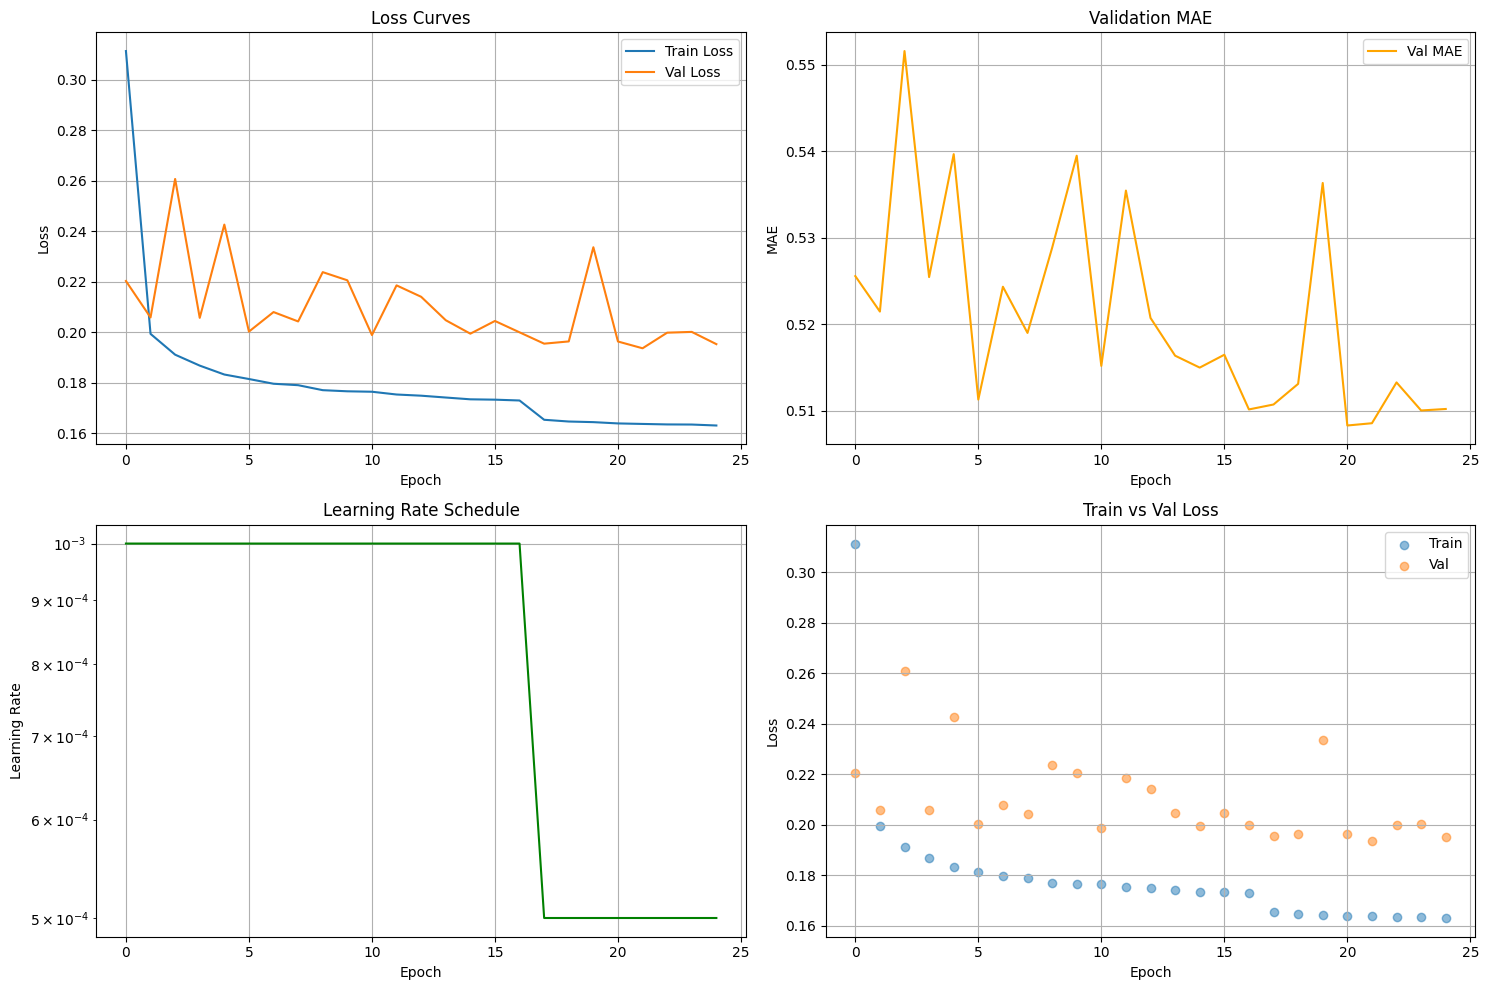

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True)

# MAE
axes[0, 1].plot(history['val_mae'], label='Val MAE', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Validation MAE')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Learning rate
axes[1, 0].plot(history['lr'], color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True)

# Loss comparison
axes[1, 1].scatter(range(len(history['train_loss'])), 
                   history['train_loss'], alpha=0.5, label='Train')
axes[1, 1].scatter(range(len(history['val_loss'])), 
                   history['val_loss'], alpha=0.5, label='Val')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Train vs Val Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150)
plt.show()

# Evaluación Final

In [32]:
# Cargar mejor modelo
checkpoint = torch.load('../models/best_model.pt')
model.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en validación
model.eval()
all_preds = []
all_targets = []
all_elasticities = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        y_hat, eps_hat, _ = model.run(batch, return_parts=True)
        
        all_preds.append(y_hat.cpu())
        all_targets.append(batch["log_liters_sold"].cpu())
        all_elasticities.append(eps_hat.cpu())

preds = torch.cat(all_preds).numpy()
targets = torch.cat(all_targets).numpy()
elasticities = torch.cat(all_elasticities).numpy()

# Métricas
mae = np.mean(np.abs(preds - targets))
mse = np.mean((preds - targets) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - (np.sum((targets - preds)**2) / np.sum((targets - targets.mean())**2))

print("Métricas Finales en Validación:")
print(f"  MAE:  {mae:.4f}")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")
print(f"\nElasticidades:")
print(f"  Media:    {elasticities.mean():.4f}")
print(f"  Mediana:  {np.median(elasticities):.4f}")
print(f"  Std:      {elasticities.std():.4f}")
print(f"  Min:      {elasticities.min():.4f}")
print(f"  Max:      {elasticities.max():.4f}")
print(f"  % Negativas: {(elasticities < 0).mean() * 100:.4f}%")

Métricas Finales en Validación:
  MAE:  0.5086
  MSE:  0.4008
  RMSE: 0.6331
  R²:   0.6331

Elasticidades:
  Media:    -1.1458
  Mediana:  -1.1218
  Std:      0.2042
  Min:      -2.9007
  Max:      0.5692
  % Negativas: 99.9878%


# Analisis Predicciones

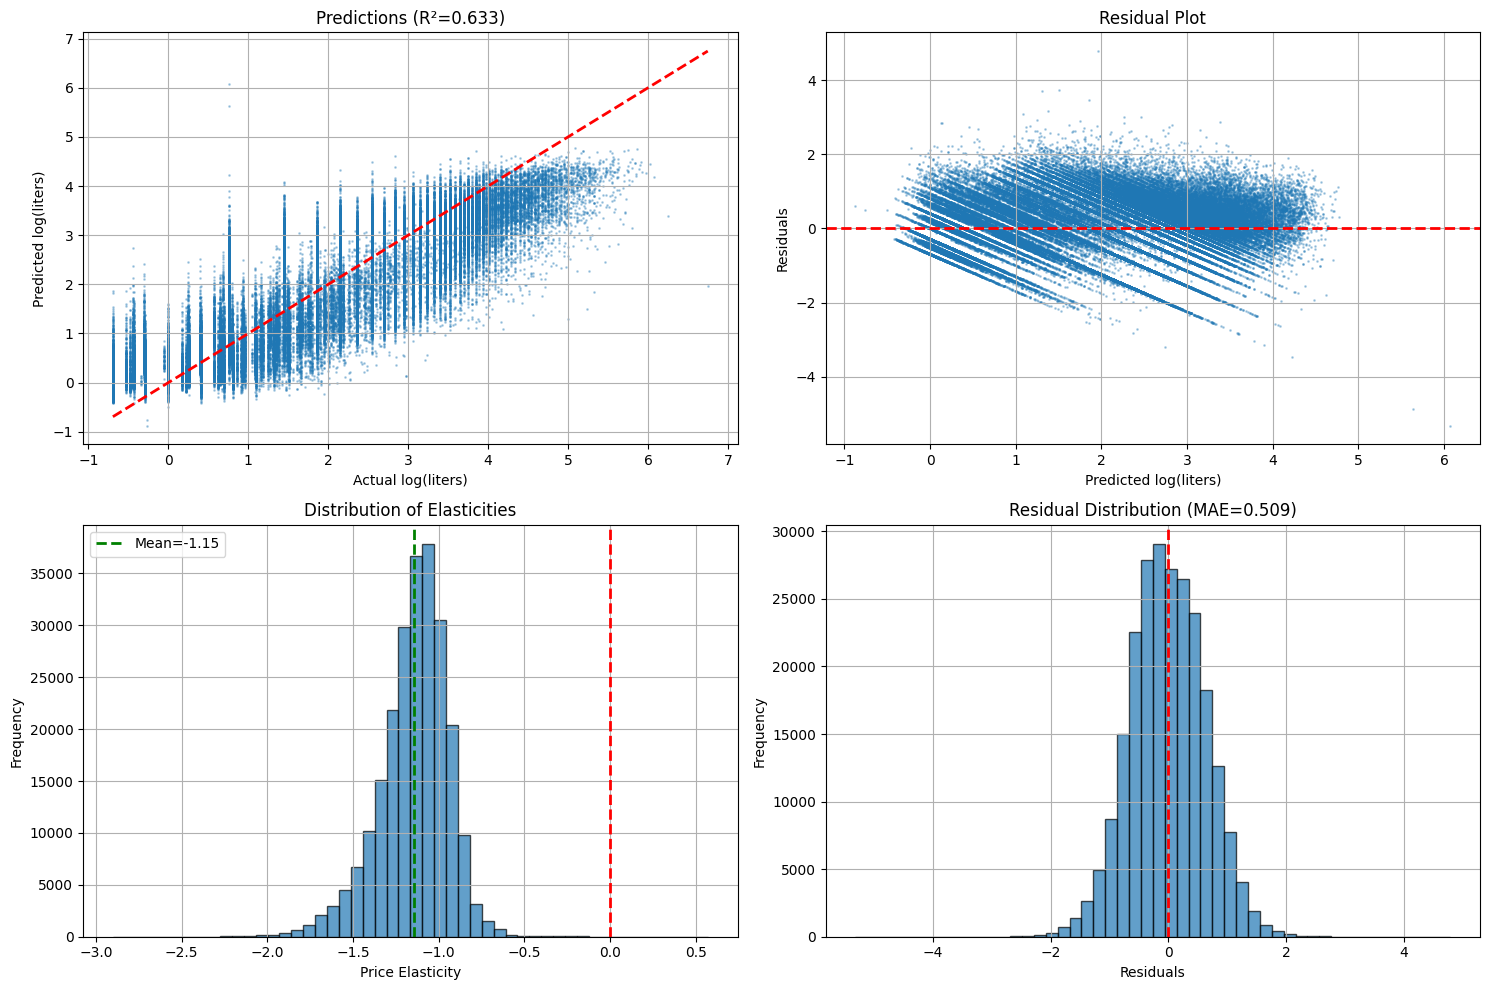


✓ Pipeline completado exitosamente


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Predicted vs Actual
axes[0, 0].scatter(targets, preds, alpha=0.3, s=1)
axes[0, 0].plot([targets.min(), targets.max()], 
                [targets.min(), targets.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual log(liters)')
axes[0, 0].set_ylabel('Predicted log(liters)')
axes[0, 0].set_title(f'Predictions (R²={r2:.3f})')
axes[0, 0].grid(True)

# Residuals
residuals = targets - preds
axes[0, 1].scatter(preds, residuals, alpha=0.3, s=1)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted log(liters)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True)

# Distribution of elasticities
axes[1, 0].hist(elasticities, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].axvline(x=elasticities.mean(), color='green', linestyle='--', lw=2, 
                   label=f'Mean={elasticities.mean():.2f}')
axes[1, 0].set_xlabel('Price Elasticity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Elasticities')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Residual distribution
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Residual Distribution (MAE={mae:.3f})')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('../results/evaluation_plots.png', dpi=150)
plt.show()

print("\n✓ Pipeline completado exitosamente")